In [1]:
import argparse
import at
from pySC import disable_pySC_rich
from pySC.configuration.generation import generate_SC
from pySC.tuning.response_measurements import measure_OrbitResponseMatrix
from pySC.tuning.response_measurements import measure_RFFrequencyOrbitResponse
from pySC.tuning.averaging import get_average_orbit
from run_pyloco_from_model import run_pyloco_from_model
from set_correction import last_by_sorted_key, get_quads_block, set_correction
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np
disable_pySC_rich()
scale_errors = 1
seed = 1
yaml_filepath = 'ebs_conf_betamodel.yaml'
SC = generate_SC(yaml_filepath, seed=1, scale_errors=scale_errors, sigma_truncate=3)

# calculates model response matrices and saves them in the specified folder
# you can comment this out after the second run
#SC.tuning.calculate_model_trajectory_response_matrix(n_turns=1, save_as='trajectory1.json')
#SC.tuning.calculate_model_trajectory_response_matrix(n_turns=2, save_as='trajectory2.json')
#SC.tuning.calculate_model_orbit_response_matrix(save_as='orbit.json')


# set reference orbit to the design orbit
x_design, y_design = SC.bpm_system.capture_orbit(use_design=True)
SC.bpm_system.reference_x = x_design
SC.bpm_system.reference_y = y_design

# set multipoles to 0
SC.tuning.set_multipole_scale(scale=0)

# 1-turn threading
for _ in range(5):
    SC.tuning.correct_injection(parameter=50, n_reps=1, n_turns=1, gain=0.8)
# 2-turn threading
for _ in range(5):
    SC.tuning.correct_injection(parameter=50, n_reps=1, n_turns=2, gain=0.8)

# orbit correction
for _ in range(5):
    SC.tuning.correct_orbit(parameter=50, n_reps=1, gain=0.2)

# bba
SC.tuning.generate_orbit_bba_config(max_dx_at_bpm=200e-6, max_modulation=20e-6)
SC.tuning.do_parallel_orbit_bba(bpm_names=SC.bpm_system.names[:20], omp_num_threads=4)

# save-reload
SC.to_json('ESRF_pySC_state.json')
#SimulatedCommissioning.from_json('ESRF_pySC_state.json')


# pyLOCO


# ORM, dispersion and BPM noise measurements

HCORR = SC.tuning.HCORR
VCORR = SC.tuning.VCORR
orm = measure_OrbitResponseMatrix(SC, HCORR, VCORR, dkick = 100e-6, normalize=False, bipolar=True) #[BPMS x cor] in meter
eta =  measure_RFFrequencyOrbitResponse(SC, delta_frf =200, normalize = False, bipolar=True)
etax = eta[:len(eta)//2] # meter
etay = eta[len(eta)//2:] # meter
x, y, x_std, y_std = get_average_orbit(SC, 100)
sigma_w = np.concatenate((x_std, y_std))  # meter

# save measurements in proper unit and format
os.makedirs("./data", exist_ok=True)

with h5py.File("./data/measured_orm_loco.h5", "w") as f:
    f.create_dataset("response_matrix", data=orm)

with h5py.File("./data/measured_dispersion_loco.h5", "w") as f:
    f.create_dataset("measured_eta_x", data=etax)
    f.create_dataset("measured_eta_y", data=etay)
    f.attrs["delta_frf"] = 200

with h5py.File("./data/measured_BPM_noise_loco.h5", "w") as f:
    f.create_dataset("Noise_BPMx", data=x_std)
    f.create_dataset("Noise_BPMy", data=y_std)

Scaling error_table by 1
29 Oct 2025, 15:10:49 | INFO | Loading AT lattice from betamodel.mat


/Users/elafmusa/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


29 Oct 2025, 15:10:52 | INFO | Configuring magnets...
29 Oct 2025, 15:10:52 | INFO | Found 632 (DL) matching regex '^DL', excluding regex '.*_MARKER'
29 Oct 2025, 15:10:52 | INFO | Found 99 (DQ) matching regex '^DQ', excluding regex '.*_MARKER'
29 Oct 2025, 15:10:53 | INFO | Found 514 (quadrupoles) matching regex '^QD|^QF'
29 Oct 2025, 15:10:53 | INFO | Found 192 (sextupoles) matching regex '^SJ|^SF|^SD|^SI'
29 Oct 2025, 15:10:53 | INFO | Found 64 (octupoles) matching regex '^O'
29 Oct 2025, 15:10:53 | INFO | Found 96 (correctors) matching regex '^SH'
29 Oct 2025, 15:10:53 | INFO | Configuring BPMs...
29 Oct 2025, 15:10:53 | INFO | Found 320 (bpms) matching regex '^BPM', excluding regex 'BPM_TFB|BPM_LFB|BPM_CUR'
29 Oct 2025, 15:10:53 | INFO | Configuring rf...
29 Oct 2025, 15:10:53 | INFO | Found 13 (main) matching regex '^CAV'
29 Oct 2025, 15:10:53 | INFO | Configuring supports...
29 Oct 2025, 15:10:53 | INFO | Resolving supports: looping through L0
29 Oct 2025, 15:10:53 | INFO | Conf

/Users/elafmusa/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)
/Users/elafmusa/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)
/Users/elafmusa/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)
/Users/elafmusa/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplica

29 Oct 2025, 15:15:00 | INFO | PID: 43412 | O. BBA: Name=10, number=0, new H. offset = -2.0 +- 0.2 um, true is -2.1 um
29 Oct 2025, 15:15:01 | INFO | PID: 43413 | O. BBA: Name=34, number=1, new H. offset = -2.7 +- 0.1 um, true is -2.8 um
29 Oct 2025, 15:15:02 | INFO | PID: 43414 | O. BBA: Name=46, number=2, new H. offset = -1.0 +- 0.1 um, true is -0.8 um
29 Oct 2025, 15:15:03 | INFO | PID: 43416 | O. BBA: Name=61, number=3, new H. offset = -1.9 +- 0.2 um, true is -0.9 um
29 Oct 2025, 15:15:04 | INFO | PID: 43412 | O. BBA: Name=10, number=0, new V. offset = -0.9 +- 0.0 um, true is -0.8 um
29 Oct 2025, 15:15:05 | INFO | PID: 43413 | O. BBA: Name=34, number=1, new V. offset = -0.4 +- 0.0 um, true is -0.8 um
29 Oct 2025, 15:15:06 | INFO | PID: 43414 | O. BBA: Name=46, number=2, new V. offset = -1.2 +- 0.0 um, true is -0.7 um
29 Oct 2025, 15:15:07 | INFO | PID: 43416 | O. BBA: Name=61, number=3, new V. offset = 0.9 +- 0.0 um, true is 0.5 um
29 Oct 2025, 15:15:09 | INFO | PID: 43412 | O. BBA

/Users/elafmusa/Desktop/pyLOCO/Examples/EBS_pySC/analyze_ring.py:174: SyntaxWarning: invalid escape sequence '\m'
  plot_data(s_pos, orbit_x * 1e6, "s [m]", "Horizontal orbit $[\mu\mathrm{m}]$", "Horizontal closed orbit")
/Users/elafmusa/Desktop/pyLOCO/Examples/EBS_pySC/analyze_ring.py:175: SyntaxWarning: invalid escape sequence '\m'
  plot_data(s_pos, orbit_y * 1e6, "s [m]", "Vertical orbit $[\mu\mathrm{m}]$", "Vertical closed orbit")


Before_pyLOCO_iteration
----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :   5.5587 µm
RMS vertical orbit           :   7.1750 µm
RMS horizontal beta beating  :   5.4271 %
RMS vertical beta beating    :   5.0838 %
RMS horizontal dispersion err:   2.0500 mm
RMS vertical dispersion err  :   0.0818 mm
Ideal Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Ideal Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569021e-03]
Tune                         : [7.61578210e+01 2.73360223e+01 3.68178125e-03]
Chromaticity                 : [-1.08564596e+02 -8.18859178e+01  3.07862558e-02]
Ideal emittance_h 140.8391273379139 emittance_v 0.0
With errors emittance_h 142.42025201692294 emittance_v 0.0
----------------------------------------------------------------------


/Users/elafmusa/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)



==== Iteration 1/5 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS_pySC/output/quad_jacobian_logs.txt'
Initial Chi²: 5.3048e+06


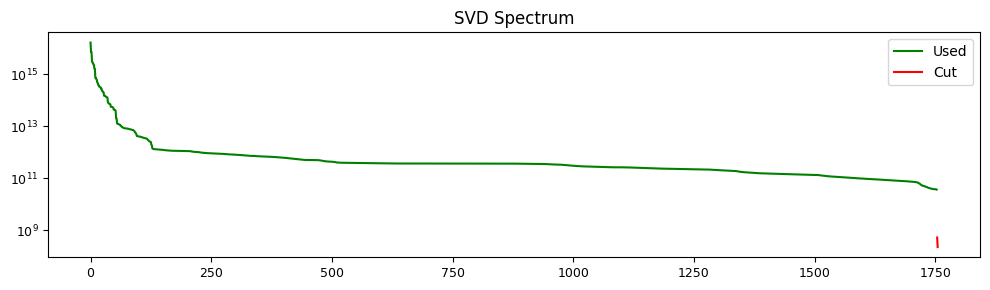

  LM inner 1: chi² 8.6048e+04 (previous 5.3048e+06), λ=0.001
Chi² after correction: 8.6048e+04

==== Iteration 2/5 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS_pySC/output/quad_jacobian_logs.txt'
Initial Chi²: 8.6048e+04


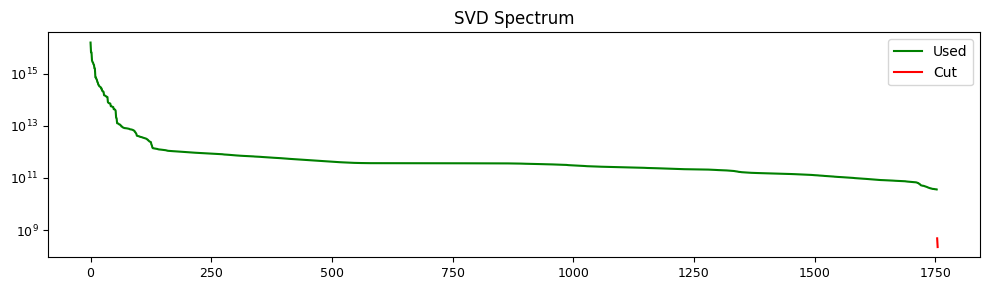

  LM inner 1: chi² 7.0388e+04 (previous 8.6048e+04), λ=0.001
Chi² after correction: 7.0388e+04

==== Iteration 3/5 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS_pySC/output/quad_jacobian_logs.txt'
Initial Chi²: 7.0291e+04


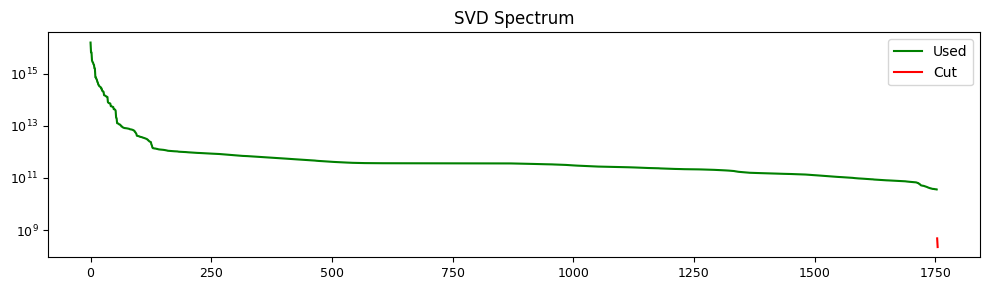

  LM inner 1: chi² 6.9862e+04 (previous 7.0291e+04), λ=0.001
Chi² after correction: 6.9862e+04

==== Iteration 4/5 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS_pySC/output/quad_jacobian_logs.txt'
Initial Chi²: 6.9862e+04


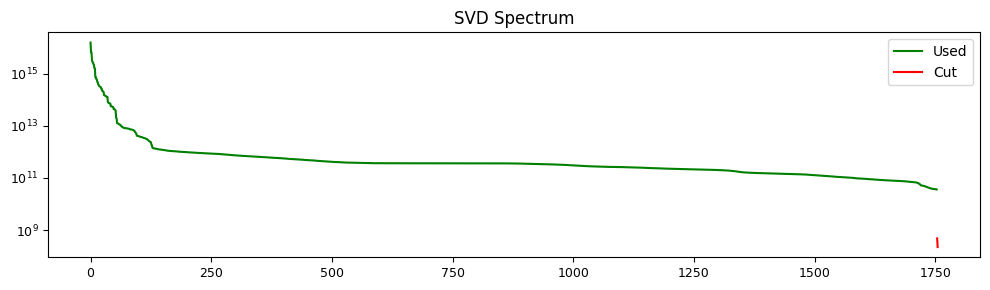

  LM inner 1: chi² 6.9707e+04 (previous 6.9862e+04), λ=0.001
Chi² after correction: 6.9707e+04

==== Iteration 5/5 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/EBS_pySC/output/quad_jacobian_logs.txt'
Initial Chi²: 6.9707e+04


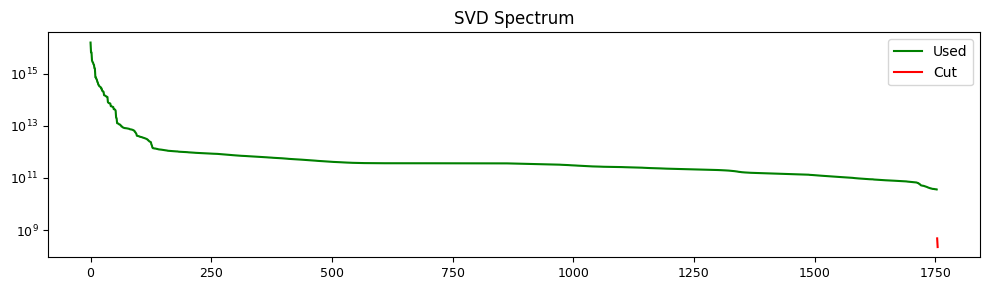

  LM inner 1: chi² 6.9618e+04 (previous 6.9707e+04), λ=0.001
Chi² after correction: 6.9618e+04
LOCO LM completed! :).


In [2]:
from analyze_ring import analyze_ring

print('Before_pyLOCO_iteration')
elements_ind = at.get_refpts(SC.lattice.design, '*')
analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

# run pyloco
orm = np.hstack((orm, eta.reshape(-1, 1))) #When include_dispersion is true in the config
config_path =  os.path.abspath("pyloco_config.py")
current_fit_parameters, fit_parameters_dic, ring_pyloco = run_pyloco_from_model(
                        orm, sigma_w,  etax,  etay,  config_path=config_path
                    )

In [4]:
# apply correction

quad_indices = at.get_refpts(SC.lattice.design, at.elements.Quadrupole)
QD3 = at.get_refpts(SC.lattice.design, 'QD3[AE]*')
QF4 = at.get_refpts(SC.lattice.design, 'QF4[ABDE]*')
QD5 = at.get_refpts(SC.lattice.design, 'QD5[BD]*')
combined = np.concatenate((QD3, QF4, QD5))
quad_indices = np.sort(combined)
skew_ord = at.get_refpts(SC.lattice.design, 'S[HFDIJ]*')
inner = last_by_sorted_key(fit_parameters_dic)
quads_fit, skew_fit = get_quads_block(inner)
delta_q = np.asarray(
[quads_fit[i] - SC.lattice.design[quad_indices[i]].K for i in range(len(quad_indices))],
dtype = float
).ravel()

#delta_skew = np.asarray(
#[skew_fit[i] - SC.lattice.design[skew_ord[i]].K for i in range(len(skew_ord))],
#dtype = float
#).ravel()

set_correction(SC, -delta_q, quad_indices, individuals=True, skewness=False)
#set_correction(SC, -delta_skew, skew_ord, individuals=True, skewness=True)

print('After_pyLOCO_iteration')
_, _, twiss0 = at.get_optics(SC.lattice.design, elements_ind)
analyze_ring(SC, twiss0, elements_ind, useIdealRing=False, makeplot=False)

After_pyLOCO_iteration
----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :   5.5828 µm
RMS vertical orbit           :   7.1789 µm
RMS horizontal beta beating  :   0.8033 %
RMS vertical beta beating    :   0.8587 %
RMS horizontal dispersion err:   3.8303 mm
RMS vertical dispersion err  :   0.0997 mm
Ideal Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Ideal Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569021e-03]
Tune                         : [7.61510355e+01 2.73399389e+01 3.68339090e-03]
Chromaticity                 : [-1.08150894e+02 -8.17043647e+01  3.10236231e-02]
Ideal emittance_h 140.8391273379139 emittance_v 0.0
With errors emittance_h 147.3248349665549 emittance_v 0.0
----------------------------------------------------------------------
